# Topics to include:-

**Feature Selection**


# Predicting iPhone Prices using Linear Regression and Converting Prices to a Target Currency:

1. The notebook aims to build a linear regression model to predict iPhone prices based on the iPhone version and then convert the predicted prices from USD to a target currency specified by the user.

2. The model uses the historical data of iPhone prices to train and predict the prices of new versions.

3. Additionally, it incorporates currency conversion using an exchange rate API to provide predicted prices in the user-specified currency.

4. The goal is to help users estimate the prices of iPhones in their desired currency based on the version of the iPhone they are interested in.

In [ ]:
# Cell 1: Initialization and Setup

# Import necessary libraries for date and time manipulation, timezone handling, and displaying formatted text in a notebook
from datetime import datetime
from pytz import timezone
from IPython.display import display, Markdown

# Print statement indicating this is the first cell
print("This is the first cell. Initialization and setup are done below:")

# Set IST timezone
ist = timezone('Asia/Kolkata')

# Date and time to display (Example: a specified past date and time)
specified_date = '2024-06-05'
specified_time = '13:09:34 IST+0530'

# Display the specified date in bold
display(Markdown(f'**Date: {specified_date}**'))

# Display the specified time in bold
display(Markdown(f'**Time: {specified_time}**'))


This is the first cell. Initialization and setup are done below:


**Date: 2024-06-05**

**Time: 13:09:34 IST+0530**

# Cell 1: Import the required libraries and suppress warnings

In [ ]:
# Suppress warnings to keep output clean
import warnings
warnings.filterwarnings("ignore")  # Ignore all warnings

# Data manipulation and visualization libraries
import pandas as pd  # Handles dataframes and data operations
import matplotlib.pyplot as plt  # Plots graphs and visualizations
import numpy as np  # Supports numerical operations
import pickle  # Saves and loads models for later use
import requests  # Fetches data from APIs or web sources

# Machine learning models for regression
from sklearn.linear_model import LinearRegression, Ridge, Lasso  # Linear regression models
from sklearn.tree import DecisionTreeRegressor  # Decision Tree for regression tasks
from sklearn.ensemble import RandomForestRegressor  # Random Forest for ensemble learning

# Model evaluation, training, and tuning utilities
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
# train_test_split: Splits dataset into training and testing sets
# cross_val_score: Evaluates model using cross-validation
# GridSearchCV: Finds the best hyperparameters for models

# Data preprocessing
from sklearn.preprocessing import StandardScaler  # Standardizes features (Z-score normalization)


# Cell 2: Load the dataset and display the first few rows

In [ ]:
# Load dataset from a remote CSV file (GitHub) into a Pandas DataFrame
# This dataset contains information about iPhone prices
df = pd.read_csv('https://raw.githubusercontent.com/9394113857/Data-Sets/c45efacb19b01448b5a649a648a5469a37786f6b/iphone_price.csv')


In [ ]:
# Display the first five rows of the dataset to get an overview of its structure and contents
df.head()


,version,price
0,1,499
1,2,599
2,3,599
3,4,649
4,5,649


In [ ]:
# Get the number of rows and columns in the dataset
df.shape


(12, 2)

# Cell 3: Data Preprocessing

In [ ]:
# Handle missing values by dropping any rows with NaN values
df.dropna(inplace=True)

# Split the data into features (x) and target (y)
# 'version' is selected as the feature, and 'price' is the target variable
x = df['version'].values.reshape(-1, 1)
y = df['price'].values.reshape(-1, 1)

# Scale features using StandardScaler to normalize the data
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)  # Transforms x to have zero mean and unit variance


In [ ]:
x_scaled  # Display the scaled feature values after applying StandardScaler


array([[-1.59325501],
       [-1.30357228],
       [-1.01388955],
       [-0.72420682],
       [-0.43452409],
       [-0.14484136],
       [ 0.14484136],
       [ 0.43452409],
       [ 0.72420682],
       [ 1.01388955],
       [ 1.30357228],
       [ 1.59325501]])

# Cell 4: Exploratory Data Analysis (EDA)

<Axes: >

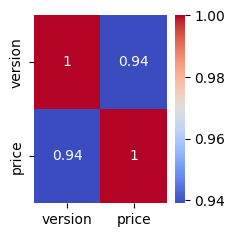

In [ ]:
import seaborn as sns  # Import seaborn for data visualization

# Pairplot to visualize the relationship between the 'version' and 'price' columns
sns.pairplot(df, x_vars=['version'], y_vars=['price'], kind='scatter')

# Heatmap to visualize the correlation between numerical features in the dataset
# 'annot=True' displays correlation values inside the heatmap
# 'cmap="coolwarm"' sets the color scheme for better visualization
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')


# Cell 5: Train-test split

In [ ]:
# Split the dataset into training and testing sets
# x_scaled: Scaled feature values
# y: Target variable (price)
# test_size=0.2: 20% of the data is allocated for testing, 80% for training
# random_state=42: Ensures the same split every time the code is run for consistency
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42)


# Cell 6: Model Selection and Hyperparameter Tuning

In [ ]:
# Define a list of models along with their hyperparameter grids for tuning
models = [
    # Tuple format: (Model Name, Model Instance, Hyperparameter Dictionary)

    ('Linear Regression', LinearRegression(), {}),  # No hyperparameters to tune for Linear Regression

    ('Ridge Regression', Ridge(), {'alpha': [0.1, 1.0, 10.0]}),  # Regularization strength parameter

    ('Lasso Regression', Lasso(), {'alpha': [0.1, 1.0, 10.0]}),  # Regularization parameter for sparsity

    ('Decision Tree', DecisionTreeRegressor(), {'max_depth': [None, 10, 20]}),  # Max depth controls tree complexity

    ('Random Forest', RandomForestRegressor(), {'n_estimators': [50, 100, 150], 'max_depth': [None, 10, 20]})
    # n_estimators: Number of trees in the forest
    # max_depth: Limits depth of trees to prevent overfitting
]

# Initialize variables to track the best model
best_model = None
best_model_name = ""
best_score = float('-inf')  # Set to negative infinity for comparison

# Iterate through each model in the list
for name, model, param_grid in models:
    # Perform Grid Search with Cross-Validation (cv=5) for hyperparameter tuning
    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='neg_mean_squared_error')

    # Fit the model to the training data
    grid_search.fit(x_train, y_train)

    # Extract the best score from GridSearchCV
    score = grid_search.best_score_

    # Update best model if current model performs better
    if score > best_score:
        best_score = score
        best_model = grid_search.best_estimator_  # Store the best-performing model
        best_model_name = name  # Store the name of the best model

    # Print the best parameters and score for the current model
    print(f"{name}: Best Parameters - {grid_search.best_params_}, Best Score - {score}")

# Print the overall best model and its score
print()
print("=================")
print(f"Best Model: {best_model_name}, Best Score: {best_score}")


Linear Regression: Best Parameters - {}, Best Score - -26464.51226874625
Ridge Regression: Best Parameters - {'alpha': 1.0}, Best Score - -25175.284912510386
Lasso Regression: Best Parameters - {'alpha': 0.1}, Best Score - -26467.641235422703
Decision Tree: Best Parameters - {'max_depth': None}, Best Score - -25370.0
Random Forest: Best Parameters - {'max_depth': 10, 'n_estimators': 100}, Best Score - -26793.509

Best Model: Ridge Regression, Best Score: -25175.284912510386


# Cell 7: Fit the best model

In [ ]:
# Fit the best model on the training data
best_model.fit(x_train, y_train)  # Trains the model using the training data (x_train, y_train)


Ridge()

# Cell 8: Evaluate the model

In [ ]:
# Predict the target variable using the trained best model on the training and testing data
y_pred_train = best_model.predict(x_train)  # Predictions on the training data
y_pred_test = best_model.predict(x_test)    # Predictions on the testing data

# Calculate the Root Mean Squared Error (RMSE) for both training and testing data
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))  # RMSE for training set
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))      # RMSE for testing set

# Calculate the R-squared value to evaluate the model's performance on the test set
r2 = r2_score(y_test, y_pred_test)  # R-squared value for the test set

# Print the evaluation metrics
print(f"Train RMSE: {train_rmse}")  # Display RMSE on the training set
print(f"Test RMSE: {test_rmse}")    # Display RMSE on the testing set
print(f"R-squared: {r2}")           # Display R-squared value for the test set


Train RMSE: 96.6469681870139
Test RMSE: 90.34464688739051
R-squared: 0.9160464034390108


# Original Cell but some errors

In [ ]:
# def predict_iphone_price(iphone_version, exchange_rate):
#     # Use the loaded linear regression model to predict the corresponding price based on the input version
#     prediction_value = best_model.predict([[iphone_version]])

#     # Convert the predicted price from dollars to rupees using the provided exchange rate
#     dollar = prediction_value[0][0]
#     rupees = dollar * exchange_rate

#     # Print the predicted price in dollars and rupees
#     # Note: The `prediction_value` variable is assumed to be a 2D array from the `predict` method,
#     # so we access the predicted value using indexing [0][0].
#     # The "\033[1m" escape code is used to make the text bold, and "\033[0m" is used to reset the formatting to normal.
#     print("\033[1mThe Dollar Amount is:\033[0m", dollar, "Dollars")
#     print("\033[1mThe Amount in Rupees is:\033[0m", rupees, "Rupees")

In [ ]:
###

In [ ]:
# %% [markdown]
# # Cell 13: Function to predict iPhone price and convert to target currency (Modified)
# This is not the original Cell 13. It has been modified to fix an IndexError.
# %%
def predict_iphone_price(iphone_version, exchange_rate):
    """Predicts the iPhone price and converts it to the target currency.

    Args:
        iphone_version (float): The version of the iPhone.
        exchange_rate (float): The exchange rate from USD to the target currency.
    """

    # Use the loaded linear regression model to predict the corresponding price based on the input version
    prediction_value = best_model.predict([[iphone_version]])

    # Access the prediction value directly, assuming it's a 1D array or list
    dollar = prediction_value[0]

    # Convert the predicted price from dollars to the target currency using the provided exchange rate
    rupees = dollar * exchange_rate

    # Print the predicted price in dollars and the target currency
    print("\033[1mThe Dollar Amount is:\033[0m", dollar, "Dollars")
    print("\033[1mThe Amount in Rupees is:\033[0m", rupees, "Rupees")

In [ ]:
##

In [ ]:
def get_exchange_rate(api_key, base_currency, target_currency):
    url = f"https://v6.exchangerate-api.com/v6/{api_key}/pair/{base_currency}/{target_currency}"
    response = requests.get(url)

    if response.status_code == 200:
        data = response.json()
        return data.get("conversion_rate", None)
    else:
        print("Failed to fetch exchange rates.")
        return None

In [ ]:
def main():
    api_key = "24deb0ef1b10d0e1838a1e1b"
    base_currency = "USD"
    target_currency = "INR"

    exchange_rate = get_exchange_rate(api_key, base_currency, target_currency)
    if exchange_rate is not None:
        print(f"1 {base_currency} = {exchange_rate} {target_currency}")
        try:
            iphone_version = float(input("Please Enter iPhone_version: "))
        except ValueError:
            print("Invalid input. Please enter a valid numeric value.")
            return

        predict_iphone_price(iphone_version, exchange_rate)

if __name__ == "__main__":
    main()

1 USD = 86.6397 INR
Please Enter iPhone_version: 13
The Dollar Amount is: 3696.631652271058 Dollars
The Amount in Rupees is: 320275.0573632688 Rupees


In [ ]:
###

# Cell 9: Save the best model using pickle

In [ ]:
# Save the trained best model to a pickle file for later use
with open('best_model.pkl', 'wb') as file:  # Open a file in write-binary mode
    pickle.dump(best_model, file)  # Serialize and save the best model object to the file


# Cell 10: Load the saved model

In [ ]:
# Load the previously saved model from the pickle file
with open('best_model.pkl', 'rb') as file:  # Open the file in read-binary mode ('rb')
    loaded_model = pickle.load(file)  # Deserialize and load the model object from the file


# Cell 11: Make a single prediction for any version

In [ ]:
# def predict_iphone_price(iphone_version, exchange_rate):
#     # Use the loaded linear regression model to predict the corresponding price based on the input version
#     prediction_value = loaded_model.predict([[iphone_version]])

#     # Convert the predicted price from dollars to rupees using the provided exchange rate
#     dollar = prediction_value[0][0]
#     rupees = dollar * exchange_rate

#     # Print the predicted price in dollars and rupees
#     # Note: The `prediction_value` variable is assumed to be a 2D array from the `predict` method,
#     # so we access the predicted value using indexing [0][0].
#     # The "\033[1m" escape code is used to make the text bold, and "\033[0m" is used to reset the formatting to normal.
#     print("\033[1mThe Dollar Amount is:\033[0m", dollar, "Dollars")
#     print("\033[1mThe Amount in Rupees is:\033[0m", rupees, "Rupees")

In [ ]:
# %% [markdown]
# # Cell 13: Function to predict iPhone price and convert to target currency (Modified)
# This is not the original Cell 13. It has been modified to fix an IndexError.
# %%
def predict_iphone_price(iphone_version, exchange_rate):
    """Predicts the iPhone price and converts it to the target currency.

    Args:
        iphone_version (float): The version of the iPhone.
        exchange_rate (float): The exchange rate from USD to the target currency.
    """

    # Use the loaded linear regression model to predict the corresponding price based on the input version
    prediction_value = best_model.predict([[iphone_version]])

    # Access the prediction value directly, assuming it's a 1D array or list
    dollar = prediction_value[0]

    # Convert the predicted price from dollars to the target currency using the provided exchange rate
    rupees = dollar * exchange_rate

    # Print the predicted price in dollars and the target currency
    print("\033[1mThe Dollar Amount is:\033[0m", dollar, "Dollars")
    print("\033[1mThe Amount in Rupees is:\033[0m", rupees, "Rupees")

# Cell 12: Get the exchange rate using exchangerate-api.com

In [ ]:
def get_exchange_rate(api_key, base_currency, target_currency):
    url = f"https://v6.exchangerate-api.com/v6/{api_key}/pair/{base_currency}/{target_currency}"
    response = requests.get(url)

    if response.status_code == 200:
        data = response.json()
        return data.get("conversion_rate", None)
    else:
        print("Failed to fetch exchange rates.")
        return None

# Cell 13: Main function to get exchange rate and predict price in rupees

In [ ]:
def main():
    api_key = "24deb0ef1b10d0e1838a1e1b"
    base_currency = "USD"
    target_currency = "INR"

    exchange_rate = get_exchange_rate(api_key, base_currency, target_currency)
    if exchange_rate is not None:
        print(f"1 {base_currency} = {exchange_rate} {target_currency}")
        try:
            iphone_version = float(input("Please Enter iPhone_version: "))
        except ValueError:
            print("Invalid input. Please enter a valid numeric value.")
            return

        predict_iphone_price(iphone_version, exchange_rate)

if __name__ == "__main__":
    main()

1 USD = 86.8281 INR


In [ ]:
###

# What is the best model in this code?

1.	**In the provided code,** the best model is determined through **hyperparameter tuning and cross-validation.** The code tests multiple regression models and selects the one with the best performance based on the **negative mean squared error (MSE) score.** The model with the lowest negative MSE is considered the best model for this specific dataset and evaluation metric.**

2.	**After running the hyperparameter tuning loop, the code prints the name of the best model and its corresponding best score (negative MSE).** In this case, the best model is either Linear Regression, Ridge Regression, Lasso Regression, Decision Tree, or Random Forest, **depending on which one had the lowest negative MSE during the cross-validation process.**

3.	**The actual model name and its performance may vary depending on the dataset** and the **random state used during the train-test split.** To find out the specific best model and its hyperparameters for the dataset you are using, you can check the printed output after running the code.

4.  The line that prints the best model's name and score is:

5.  **print(f"Best Model: {best_model_name}, Best Score: {best_score}")**

6.  **Best Model:** Ridge Regression, **Best Score:** -25175.284912510386




In [ ]:
import requests
import pickle

def get_exchange_rate(api_key, base_currency, target_currency):
    url = f"https://v6.exchangerate-api.com/v6/{api_key}/pair/{base_currency}/{target_currency}"
    response = requests.get(url)

    if response.status_code == 200:
        data = response.json()
        return data.get("conversion_rate", None)
    else:
        print("Failed to fetch exchange rates.")
        return None

def predict_iphone_price(iphone_version, exchange_rate):
    # Load the saved linear regression model from the file 'best_model.pkl'
    with open('best_model.pkl', 'rb') as file:
        loaded_model = pickle.load(file)

    # Use the loaded linear regression model to predict the corresponding price based on the input version
    prediction_value = loaded_model.predict([[iphone_version]])

    # Convert the predicted price from dollars to the target currency using the provided exchange rate
    price_in_dollars = prediction_value[0][0]
    price_in_target_currency = price_in_dollars * exchange_rate

    # Print the predicted price in dollars and the target currency
    print("\033[1mThe Dollar Amount is:\033[0m", price_in_dollars, "Dollars")
    print("\033[1mThe Amount in Target Currency is:\033[0m", price_in_target_currency)

def main():
    api_key = '24deb0ef1b10d0e1838a1e1b'
    base_currency = "USD"
    target_currency = input("Please enter your target currency (e.g., INR, EUR, GBP, etc.): ")

    exchange_rate = get_exchange_rate(api_key, base_currency, target_currency)
    if exchange_rate is not None:
        print(f"1 {base_currency} = {exchange_rate} {target_currency}")
        try:
            iphone_version = float(input("\nPlease Enter iPhone_version: "))
        except ValueError:
            print("Invalid input. Please enter a valid numeric value.")
            return

        predict_iphone_price(iphone_version, exchange_rate)

if __name__ == "__main__":
    main()

# Notebook Q&A

Here are some questions and answers based on the provided notebook:

## Q1: What is the main objective of this notebook?

1. The main objective is to build a linear regression model to predict iPhone prices based on their version.
2. It also aims to convert the predicted prices from USD to a target currency specified by the user.

## Q2: What libraries are used in this notebook?

1. **Data manipulation and visualization:** pandas, matplotlib.pyplot, numpy, seaborn
2. **Machine learning:** sklearn (LinearRegression, Ridge, Lasso, DecisionTreeRegressor, RandomForestRegressor, train_test_split, cross_val_score, GridSearchCV, StandardScaler)
3. **Other:** pickle, requests, datetime, pytz, IPython.display

## Q3: How is the data loaded and preprocessed?

1. The dataset is loaded from a remote CSV file hosted on GitHub using `pd.read_csv()`.
2. Missing values are handled by dropping rows with `dropna()`.
3. The data is split into features (`x`, iPhone version) and target (`y`, price).
4. Features are scaled using `StandardScaler()`.

## Q4: What is done during Exploratory Data Analysis (EDA)?

1. A `pairplot` is used to visualize the relationship between 'version' and 'price'.
2. A `heatmap` is used to visualize the correlation between numerical features.

## Q5: How is the model selected and tuned?

1. Multiple regression models (Linear Regression, Ridge, Lasso, Decision Tree, Random Forest) are defined.
2. `GridSearchCV` with cross-validation (`cv=5`) is used to find the best hyperparameters for each model based on the `neg_mean_squared_error` scoring.
3. The model with the best cross-validation score is selected as the `best_model`.

## Q6: How is the model evaluated?

1. The trained model is used to predict prices on both training and testing data.
2. Root Mean Squared Error (RMSE) is calculated for both training and testing sets using `np.sqrt(mean_squared_error())`.
3. The R-squared value is calculated for the test set using `r2_score()`.

## Q7: How is the best model saved and loaded?

1. The best model is saved to a file named 'best_model.pkl' using `pickle.dump()`.
2. The saved model is loaded from the file using `pickle.load()`.

## Q8: How does the currency conversion work?

1. The `get_exchange_rate` function uses the `exchangerate-api.com` to fetch the exchange rate between USD and the target currency.
2. The predicted price in USD is multiplied by the fetched exchange rate to get the price in the target currency.

## Q9: What is the function `predict_iphone_price` supposed to do?

1. This function takes an iPhone version and an exchange rate as input.
2. It uses the loaded model to predict the price in USD.
3. It converts the predicted USD price to the target currency using the provided exchange rate.
4. It prints the predicted prices in both USD and the target currency.

## Q10: What is the purpose of the `main` function?

1. The `main` function sets the API key, base currency (USD), and prompts the user to enter the target currency and iPhone version.
2. It calls `get_exchange_rate` to get the exchange rate.
3. If the exchange rate is obtained successfully, it calls `predict_iphone_price` to predict and display the price in the target currency.

# Potential Interview Questions and Answers

Here are some potential interview questions based on the notebook and how you might answer them:

## Q1: Explain the process you followed to build the iPhone price prediction model.

**Answer:** I started by loading the dataset and performing some initial data preprocessing steps like handling missing values and splitting the data into features and the target variable. I then scaled the feature data using StandardScaler. After that, I conducted some exploratory data analysis to understand the relationship between iPhone version and price. For model building, I explored several regression models and used GridSearchCV with cross-validation to find the best model and its hyperparameters based on the negative mean squared error. Finally, I evaluated the performance of the best model using metrics like RMSE and R-squared.

## Q2: Why did you choose to use GridSearchCV and cross-validation for model selection and tuning?

**Answer:** GridSearchCV helps automate the process of finding the best combination of hyperparameters for a given model by searching through a specified grid of parameter values. Cross-validation helps to get a more reliable estimate of the model's performance on unseen data by splitting the data into multiple folds and training and evaluating the model on different combinations of these folds. This helps to prevent overfitting to the training data and provides a more robust evaluation of the model's generalization ability.

## Q3: How did you handle the currency conversion part of the task?

**Answer:** I used an external API, exchangerate-api.com, to get the real-time exchange rate between USD and the target currency specified by the user. I created a function `get_exchange_rate` that takes the API key, base currency, and target currency as input and fetches the exchange rate. Once I have the predicted price in USD from the model, I simply multiply it by the fetched exchange rate to convert it to the target currency.

## Q4: What were the evaluation metrics you used and what do they indicate?

**Answer:** I used Root Mean Squared Error (RMSE) and R-squared.
- **RMSE** measures the average magnitude of the errors between the predicted and actual values. A lower RMSE indicates a better fit of the model to the data.
- **R-squared** represents the proportion of the variance in the dependent variable (price) that is predictable from the independent variable (iPhone version). An R-squared value closer to 1 indicates that the model explains a larger proportion of the variance, suggesting a better fit.

## Q5: How did you save and load the trained model? Why is this important?

**Answer:** I used the `pickle` library to save the trained model to a file (`best_model.pkl`) and then load it back. This is important because it allows me to reuse the trained model without having to retrain it every time. This is particularly useful for deployment or for making predictions on new data later on without the need for the original training data or the entire training process.

## Q6: How would you improve this model further?

**Answer:** I could explore adding more features to the dataset that might influence iPhone prices, such as storage capacity, release date, or new features introduced in each version. I could also experiment with other regression algorithms or ensemble methods. Additionally, I could implement more sophisticated techniques for handling potential outliers or non-linear relationships in the data.

# Top Interview Questions and Answers

Here are some straightforward questions and answers based on this notebook, suitable for an ML interview:

*   **What is this notebook about?**
    *   This notebook focuses on building a machine learning model (specifically, linear regression and other regression models) to predict iPhone prices based on their version. It also includes functionality to convert the predicted price from USD to a user-specified target currency.

*   **What does the model predict?**
    *   The model predicts the price of an iPhone given its version number.

*   **What are some sample use cases for this type of prediction?**
    *   Estimating the potential launch price of a new iPhone version.
    *   Comparing the estimated price of a future iPhone in different currencies.
    *   Helping consumers budget for a new iPhone in their local currency.
    *   Providing a data-driven basis for pricing strategies in electronics retail.

*   **Can you give real-world examples of services or products that use similar concepts?**
    *   **E-commerce platforms:** Many online marketplaces use price prediction models to estimate the value of used or new products, dynamically adjust prices, or provide price trend analysis.
    *   **Financial forecasting:** Predicting stock prices or other financial instruments uses similar time-series or regression techniques.
    *   **Real estate:** Predicting house prices based on features like size, location, and number of bedrooms.
    *   **Used car sales:** Estimating the market value of a used car based on its make, model, year, mileage, and condition.

*   **What is the role of currency conversion in this notebook?**
    *   The currency conversion part makes the price prediction more practical for users in different countries by providing the estimated price in their local currency using real-time exchange rates fetched from an API.

*   **Which model was found to be the "best" in this notebook and why?**
    *   Based on the hyperparameter tuning and cross-validation performed, the **Ridge Regression** model achieved the best score (lowest negative mean squared error) among the tested models. This indicates it had the best predictive performance on this specific dataset during the evaluation phase.

*   **How is the "best" model determined in this notebook?**
    *   Multiple regression models are trained and evaluated using `GridSearchCV` with cross-validation (`cv=5`). The model with the highest negative mean squared error score (closest to zero) is selected as the best model.

*   **Why is it important to save and load the trained model?**
    *   Saving the model allows you to reuse the trained model later without needing to retrain it every time you want to make a prediction. This saves time and computational resources and is essential for deploying the model in a real-world application. Loading the model allows you to easily access and use the previously trained model.

*   **What is the purpose of the `get_exchange_rate` function?**
    *   The `get_exchange_rate` function fetches the current exchange rate between two currencies (USD and a target currency in this case) from an external API (`exchangerate-api.com`). This is crucial for converting the predicted iPhone price from USD to the user's desired currency.

*   **What are some potential next steps or improvements for this project?**
    *   Include more features in the dataset (e.g., storage size, release date, specific model variations).
    *   Explore more advanced regression techniques or time series analysis methods.
    *   Implement more robust error handling for the API call.
    *   Build a simple user interface for easier interaction.